In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# do not preallocate GPU memory (jax)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = 'false'

# CPU only for now 
os.environ["JAX_PLATFORMS"] = 'cpu'

import jax
import jax.numpy as jnp
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from cond_sampling import load_model, get_latest_model, setup_sde, sample
from cond_sampling import get_score_function
import datasets
from gmm_utils import get_gmm_score_vmap, get_gmm_score, eval_log_gmm

checkpoint_path = Path('../checkpoints').absolute()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-04-29 14:42:38.354040: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
def get_empirical_gmm_score_fn(true_data, sigma):
    N = true_data.shape[0]
    emp_means = true_data # center gaussians on data
    emp_covs = jnp.repeat(sigma**2 * jnp.eye(2)[None, :, :], N, axis=0)
    emp_weights = jnp.ones(N) / N
    # log_gmm = eval_log_gmm(grid, means=emp_means, covs=emp_covs, weights=emp_weights)
    return get_gmm_score_vmap(emp_means, emp_covs, emp_weights)

In [4]:
from tqdm import tqdm

def compute_score_norms_on_grid(
    score_functions,
    train_data,
    sigma_min,
    xmin=-3,
    xmax=3,
    n_grid=200,
):
    """
    Compute score norms on a grid for multiple score functions.
    
    Args:
        score_functions: List of score functions to evaluate
        train_data: Training data for empirical score computation
        sigma_min: Minimum sigma for empirical GMM
        xmin, xmax: Grid bounds
        n_grid: Number of grid points per dimension
    
    Returns:
        dict with keys:
            - 'grid_coords': (X, Y) meshgrid coordinates
            - 'norms': List of norm arrays for each score function
            - 'empirical_norm': Empirical GMM score norm
            - 'train_data_plot': Perturbed training data for plotting
            - 'grid_params': Dict with xmin, xmax, n_grid
    """
    x = jnp.linspace(xmin, xmax, n_grid)
    y = jnp.linspace(xmin, xmax, n_grid)
    X, Y = jnp.meshgrid(x, y)
    grid = jnp.stack([X, Y], axis=-1).reshape(-1, 2)
    
    # Compute norms for all provided score functions
    norms = []
    for score_fn in score_functions:
        score = score_fn(grid, jnp.zeros(grid.shape[0])).reshape(n_grid, n_grid, 2)
        norm = jnp.linalg.norm(score, axis=-1)
        norms.append(norm)
    
    # Smoothed empirical density
    emp_gmm_score_fn = get_empirical_gmm_score_fn(train_data, sigma_min)
    emp_gmm_score = emp_gmm_score_fn(grid)
    emp_gmm_score_norms = jnp.linalg.norm(emp_gmm_score, axis=-1).reshape(n_grid, n_grid)
    
    # Perturb the train data for plotting
    data_plot = train_data + sigma_min * jax.random.normal(jax.random.PRNGKey(0), train_data.shape)
    
    return {
        'grid_coords': (X, Y),
        'norms': norms,
        'empirical_norm': emp_gmm_score_norms,
        'train_data_plot': data_plot,
        'grid_params': {'xmin': xmin, 'xmax': xmax, 'n_grid': n_grid}
    }

In [5]:
def plot_score_norms(
    disco_score_fn,
    no_disco_score_fn,
    t_indep_dm_score_fn,
    train_data,
    sigma_min,
    xmin=-3,
    xmax=3,
    n_grid=200,
    plot_path='plots/scores_moons.pdf',
):
    """Legacy function - now uses the refactored functions internally."""
    # Compute norms using the new function
    score_functions = [disco_score_fn, t_indep_dm_score_fn, no_disco_score_fn]
    norm_data = compute_score_norms_on_grid(
        score_functions=score_functions,
        train_data=train_data,
        sigma_min=sigma_min,
        xmin=xmin,
        xmax=xmax,
        n_grid=n_grid,
    )
    
    # Prepare data for plotting
    titles = [
        'Train Data',
        'Norm of Empirical Scores',
        'Norm of DISCO Scores',
        'Norm of t-indep. DM Scores',
        'Norm of t=0 DM Scores'
    ]
    
    row_data = {
        'norms': norm_data['norms'],
        'empirical_norm': norm_data['empirical_norm'],
        'train_data_plot': norm_data['train_data_plot'],
        'titles': titles,
        'grid_params': norm_data['grid_params']
    }
    
    # Plot using the new function
    plot_score_norms_grid([row_data], plot_path=plot_path)


def plot_score_norms_for_model(disco_model_name, no_disco_model_name, t_indep_dm_model_name, checkpoint_path, dataset_name, 
                               xmin=-2.5, xmax=2.5, n_grid=200, step=None):
    disco_state, disco_config, disco_score_model, disco_model_dir = load_model(disco_model_name, checkpoint_path, step=step)
    disco_sde, disco_sampling_eps = setup_sde(disco_config)
    disco_score_fn = get_score_function(disco_sde, disco_score_model, disco_state, disco_config)

    no_disco_state, no_disco_config, no_disco_score_model, no_disco_model_dir = load_model(no_disco_model_name, checkpoint_path, step=step)
    no_disco_sde, no_disco_sampling_eps = setup_sde(no_disco_config)
    no_disco_score_fn = get_score_function(no_disco_sde, no_disco_score_model, no_disco_state, no_disco_config)

    t_indep_dm_state, t_indep_dm_config, t_indep_dm_score_model, t_indep_dm_model_dir = load_model(t_indep_dm_model_name, checkpoint_path, step=step)
    t_indep_dm_sde, t_indep_dm_sampling_eps = setup_sde(t_indep_dm_config)
    t_indep_dm_score_fn = get_score_function(t_indep_dm_sde, t_indep_dm_score_model, t_indep_dm_state, t_indep_dm_config)

    num_samples = 2000 #10*1024
    disco_config.training.batch_size = num_samples

    # Get dataset
    train_ds, eval_ds, _ = datasets.get_dataset(disco_config)

    train_data = next(iter(train_ds))['image']
    train_data = jnp.array(train_data).reshape(train_data.shape[1], -1)
    sigma_min = disco_config.model.sigma_min

    print('Sigma min: ', sigma_min)

    # Call the function with the current parameters
    plot_score_norms(
        disco_score_fn=disco_score_fn,
        no_disco_score_fn=no_disco_score_fn,
        t_indep_dm_score_fn=t_indep_dm_score_fn,
        train_data=train_data,
        sigma_min=disco_config.model.sigma_min,
        xmin=xmin,
        xmax=xmax,
        n_grid=n_grid,
        plot_path=f'plots/scores_{dataset_name}.pdf',
    )

    # del all variables that take memory
    del disco_state, no_disco_state, t_indep_dm_state, train_data


In [6]:
def plot_score_norms_grid(
    norm_data_rows,
    plot_path='plots/scores_comparison.pdf',
    figsize_per_row=(6, 1.25),  # slightly reduce vertical size per row
):
    """
    Plot score norms for multiple rows of data, with one colorbar per row.

    Args:
        norm_data_rows: List of dicts, each containing:
            - 'norms': List of norm arrays
            - 'empirical_norm': Empirical norm array
            - 'train_data_plot': Training data for scatter plot
            - 'titles': List of titles for each subplot
            - 'grid_params': Dict with xmin, xmax, n_grid
            - 'row_title': Title for the entire row (optional)
        plot_path: Path to save the plot
        figsize_per_row: Figure size per row
    """
    n_rows = len(norm_data_rows)
    n_cols = len(norm_data_rows[0]['norms']) + 2  # +2 for train data and empirical

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_row[0], figsize_per_row[1] * n_rows))

    # Handle single row case
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    # Store the last imshow handle for each row for colorbar
    im_handles = []

    for row_idx, row_data in enumerate(norm_data_rows):
        norms = row_data['norms']
        empirical_norm = row_data['empirical_norm']
        train_data_plot = row_data['train_data_plot']
        titles = row_data['titles']
        grid_params = row_data['grid_params']
        xmin, xmax = grid_params['xmin'], grid_params['xmax']

        # Combine all norms for consistent colorbar scaling
        all_norms = [empirical_norm] + norms
        vmin = min(norm.min() for norm in all_norms)
        vmax = max(norm.max() for norm in all_norms)

        # Plot train data
        ax = axes[row_idx, 0]
        ax.scatter(np.array(train_data_plot)[:, 0], np.array(train_data_plot)[:, 1], s=2, alpha=0.5)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        if row_idx == 0:
            ax.set_title(titles[0])
        ax.set_aspect('equal')

        # Remove all ticks and spines except left/bottom
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(True)
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_visible(True)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Plot empirical norm
        ax = axes[row_idx, 1]
        im = ax.imshow(empirical_norm, cmap='viridis', extent=[xmin, xmax, xmin, xmax],
                      origin='lower', vmin=vmin, vmax=vmax)
        if row_idx == 0:
            ax.set_title(titles[1])
        ax.set_aspect('equal')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(True)
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_visible(True)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Plot other norms
        for i, norm in enumerate(norms):
            ax = axes[row_idx, i + 2]
            im = ax.imshow(norm, cmap='viridis', extent=[xmin, xmax, xmin, xmax],
                          origin='lower', vmin=vmin, vmax=vmax)
            if row_idx == 0:
                ax.set_title(titles[i + 2])
            ax.set_aspect('equal')

            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(True)
            for spine in ['left', 'bottom']:
                ax.spines[spine].set_visible(True)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')

        # Store the last imshow handle for colorbar (any im is fine, all share vmin/vmax)
        im_handles.append(im)

    # Add one colorbar per row, to the right of the row
    fig.subplots_adjust(right=0.91, hspace=0.05, wspace=0.01)  # Make room for colorbars, reduce vertical space
    for row_idx, im in enumerate(im_handles):
        # Calculate colorbar position for each row
        # [left, bottom, width, height] in figure coordinates
        n_total_rows = n_rows
        row_height = 0.9 / n_total_rows
        # cbar_height = row_height * 0.9
        cbar_height = row_height * 0.82
        # Center the colorbar vertically within the row
        # bottom = 0.05 + row_idx * row_height + (row_height - cbar_height) / 2
        # bottom = 0.03 + row_idx * (row_height + 0.011) #+ (row_height - cbar_height) / 2
        bottom = 0.045 + row_idx * (row_height - 0.003) #+ (row_height - cbar_height) / 2
        cbar_ax = fig.add_axes([0.93, bottom, 0.015, cbar_height])
        fig.colorbar(im, cax=cbar_ax)
        # numbers should be on the left
        cbar_ax.yaxis.set_ticks_position('right')
        cbar_ax.yaxis.set_label_position('right')
        # cbar_ax.xaxis.set_ticks([])
        # cbar_ax.yaxis.set_ticks([])

    plt.tight_layout(rect=[0, 0, 0.91, 1])
    import os
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    # plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.savefig(plot_path, bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:
# Example: Using the new refactored functions to plot multiple rows
def plot_score_norms_for_multiple_models(model_configs, checkpoint_path, dataset_name, 
                                        xmin=-2.5, xmax=2.5, n_grid=200, step=None):
    """
    Plot score norms for multiple model configurations in separate rows.
    
    Args:
        model_configs: List of dicts, each containing:
            - 'disco_model_name': Name of disco model
            - 'no_disco_model_name': Name of no disco model  
            - 't_indep_dm_model_name': Name of t-independent DM model
            - 'row_title': Title for this row (optional)
        checkpoint_path: Path to checkpoints
        dataset_name: Name of dataset
        xmin, xmax: Grid bounds
        n_grid: Grid resolution
        step: Model step to load (optional)
    """
    norm_data_rows = []
    
    for config in model_configs:
        # Load models
        disco_state, disco_config, disco_score_model, disco_model_dir = load_model(
            config['disco_model_name'], checkpoint_path, step=step)
        disco_sde, disco_sampling_eps = setup_sde(disco_config)
        disco_score_fn = get_score_function(disco_sde, disco_score_model, disco_state, disco_config)

        no_disco_state, no_disco_config, no_disco_score_model, no_disco_model_dir = load_model(
            config['no_disco_model_name'], checkpoint_path, step=step)
        no_disco_sde, no_disco_sampling_eps = setup_sde(no_disco_config)
        no_disco_score_fn = get_score_function(no_disco_sde, no_disco_score_model, no_disco_state, no_disco_config)

        t_indep_dm_state, t_indep_dm_config, t_indep_dm_score_model, t_indep_dm_model_dir = load_model(
            config['t_indep_dm_model_name'], checkpoint_path, step=step)
        t_indep_dm_sde, t_indep_dm_sampling_eps = setup_sde(t_indep_dm_config)
        t_indep_dm_score_fn = get_score_function(t_indep_dm_sde, t_indep_dm_score_model, t_indep_dm_state, t_indep_dm_config)

        # Get dataset
        num_samples = 2000 # 10*1024
        disco_config.training.batch_size = num_samples
        train_ds, eval_ds, _ = datasets.get_dataset(disco_config)
        train_data = next(iter(train_ds))['image']
        train_data = jnp.array(train_data).reshape(train_data.shape[1], -1)
        sigma_min = disco_config.model.sigma_min

        # Compute norms using the new function
        score_functions = [disco_score_fn, t_indep_dm_score_fn, no_disco_score_fn]
        norm_data = compute_score_norms_on_grid(
            score_functions=score_functions,
            train_data=train_data,
            sigma_min=sigma_min,
            xmin=xmin,
            xmax=xmax,
            n_grid=n_grid,
        )
        
        titles = [
            'Data',
            'Empirical',
            'DISCO',
            r'$t$-indep. DM',
            r'$t=0$ DM'
        ]
        
        row_data = {
            'norms': norm_data['norms'],
            'empirical_norm': norm_data['empirical_norm'],
            'train_data_plot': norm_data['train_data_plot'],
            'titles': titles,
            'grid_params': norm_data['grid_params'],
            'row_title': config.get('row_title', f'Config {len(norm_data_rows)+1}')
        }
        
        norm_data_rows.append(row_data)
        
        # Clean up memory
        del disco_state, no_disco_state, t_indep_dm_state, train_data
    
    # Plot all rows using the new function
    plot_score_norms_grid(
        norm_data_rows, 
        plot_path=f'plots/scores_{dataset_name}_comparison.pdf'
    )


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250917-130104_moons_disco_ebm_weight_free_inv_sigma_sq_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.1_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_
Loaded model at step 100010


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250917-130234_moons_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_
Loaded model at step 100010
Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250914-112110_moons_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_


Loaded model at step 200010


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250913-183152_checkerboard_disco_ebm_weight_free_inv_sigma_sq_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.1_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_
Loaded model at step 200010


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250913-183353_checkerboard_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_
Loaded model at step 200010
Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250914-105641_checkerboard_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_


Loaded model at step 200010


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250915-163051_None_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.05_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.05_smax=2.0_
Loaded model at step 100010


Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250915-163046_rings_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.05_smax=2.0_
Loaded model at step 100010
Loading checkpoint from: /home/twede/PhD/Research/disco/experiments_moons/../checkpoints/20250915-111659_rings_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_


Loaded model at step 100010


/tmp/ipykernel_2282464/3449296401.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


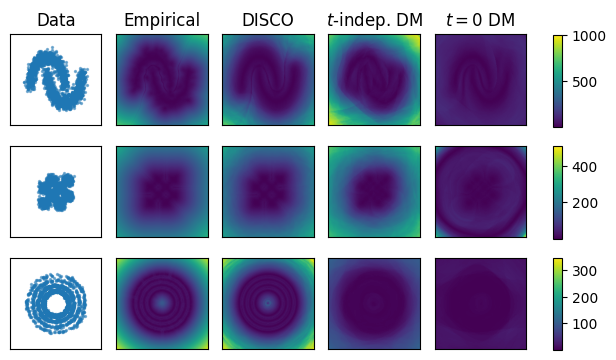

In [ ]:
moons_configs = {
    't_indep_dm_model_name': '20250914-112110_moons_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_',
    'disco_model_name': '20250917-130104_moons_disco_ebm_weight_free_inv_sigma_sq_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.1_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_',
    'no_disco_model_name': '20250917-130234_moons_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_'
}

checkerboard_config = {
    'disco_model_name': '20250913-183152_checkerboard_disco_ebm_weight_free_inv_sigma_sq_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.1_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_',
    'no_disco_model_name': '20250913-183353_checkerboard_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_',
    't_indep_dm_model_name': '20250914-105641_checkerboard_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_'
}

rings_config = {
    'disco_model_name': '20250915-163051_None_ncsnv2_lowdim_ebm_sigma_times_eps_loss_variant=inv_sigma_sq_weighting_centered=False_fixed_sigma_is=0.05_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.05_smax=2.0_',
    'no_disco_model_name': '20250915-163046_rings_no_disco_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.05_smax=2.0_',
    't_indep_dm_model_name': '20250915-111659_rings_t_indep_dm_ebm_eps_no_sigma_weights_ncsnv2_lowdim_ebm_eps_centered=False_fixed_sigma_is=None_fixed_sigma_baseline=None_lr=0.0001_batch_size=1024_nf=128_smin=0.1_smax=2.0_'
}

model_configs = [moons_configs, checkerboard_config, rings_config]
plot_score_norms_for_multiple_models(model_configs, checkpoint_path, dataset_name='non-minibatch', xmin=-3.0, xmax=3.0)